# Библиотеки

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler 
import numpy as np
from sklearn.model_selection import train_test_split
import os, cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D

In [4]:
# import coremltools as ct

# Загрузка данных

In [5]:
import pandas as pd
data = pd.read_csv('./skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv')
data.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [6]:
y = data['label']
x = data.drop(columns = ['label'])

# Анализ данных

In [7]:
tabular_data = pd.read_csv('./skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
tabular_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
tabular_data[tabular_data['image_id'] == 'ISIC_0024319']

,lesion_id,image_id,dx,dx_type,age,sex,localization
8123,HAM_0003062,ISIC_0024319,nv,histo,55.0,male,lower extremity


In [9]:
classes = {4: ('nv', ' melanocytic nevi'), 6: ('mel', 'melanoma'), 2 :('bkl', 'benign keratosis-like lesions'), 1:('bcc' , ' basal cell carcinoma'), 5: ('vasc', ' pyogenic granulomas and hemorrhage'), 0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),  3: ('df', 'dermatofibroma')}

# Распределение классов

Text(0.5, 1.0, 'Frequency Distribution of Classes')

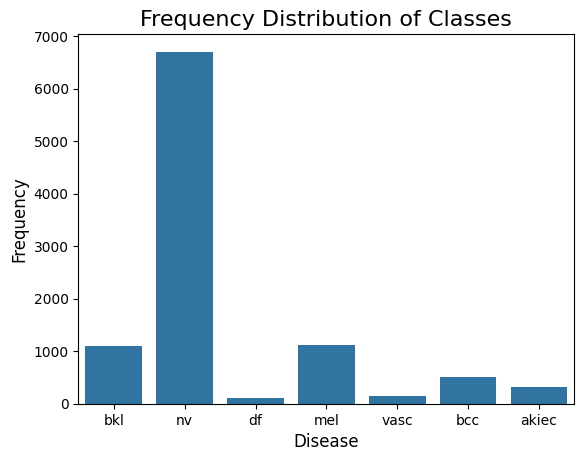

In [10]:
sns.countplot(x = 'dx', data = tabular_data)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency', size=12)
plt.title('Frequency Distribution of Classes', size=16)

# Oversampling
**To overcome class imbalace**

In [11]:
oversample = RandomOverSampler()
x,y = oversample.fit_resample(x,y)

In [12]:
x = np.array(x).reshape(-1,28,28,3)
print('Shape of X :',x.shape)

Shape of X : (46935, 28, 28, 3)


# Нормализация и разбиение

In [13]:
x = x / float(255)
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Обучение модели

In [14]:
model = Sequential()
model.add(Conv2D(16, kernel_size = (3,3), input_shape = (28, 28, 3), activation = 'relu', padding = 'same'))
model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))
model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu', padding = 'same'))
model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.summary()

/Users/z123/Desktop/SCHOOL21/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,663 (713.53 KB)

 Trainable params: 182,663 (713.53 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callback = tf.keras.callbacks.ModelCheckpoint(filepath='model.h5',
                                                  monitor='val_acc', mode='max',
                                                 verbose=1)


In [16]:
model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer = 'adam',
              metrics = ['accuracy'])
history = model.fit(tf.convert_to_tensor(X_train),
                    tf.convert_to_tensor(Y_train),
                    validation_split=0.2,
                    batch_size = 128,
                    epochs = 15,
                    callbacks=[callback])

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2560 - loss: 1.7816
Epoch 1: saving model to model.h5



Epoch 1: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.3650 - loss: 1.5768 - val_accuracy: 0.5272 - val_loss: 1.2000
Epoch 2/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5547 - loss: 1.1513
Epoch 2: saving model to model.h5



Epoch 2: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.5745 - loss: 1.1102 - val_accuracy: 0.6216 - val_loss: 0.9882
Epoch 3/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6431 - loss: 0.9419
Epoch 3: saving model to model.h5



Epoch 3: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6634 - loss: 0.8942 - val_accuracy: 0.6859 - val_loss: 0.8000
Epoch 4/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7114 - loss: 0.7660
Epoch 4: saving model to model.h5



Epoch 4: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7210 - loss: 0.7454 - val_accuracy: 0.7613 - val_loss: 0.6601
Epoch 5/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7623 - loss: 0.6399
Epoch 5: saving model to model.h5


...


Epoch 11: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9063 - loss: 0.2568 - val_accuracy: 0.8830 - val_loss: 0.3135
Epoch 12/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9133 - loss: 0.2410
Epoch 12: saving model to model.h5



Epoch 12: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9147 - loss: 0.2383 - val_accuracy: 0.8838 - val_loss: 0.3038
Epoch 13/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9271 - loss: 0.2062
Epoch 13: saving model to model.h5



Epoch 13: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9256 - loss: 0.2123 - val_accuracy: 0.9043 - val_loss: 0.2576
Epoch 14/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9322 - loss: 0.1836
Epoch 14: saving model to model.h5



Epoch 14: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9346 - loss: 0.1825 - val_accuracy: 0.9246 - val_loss: 0.2201
Epoch 15/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9427 - loss: 0.1601
Epoch 15: saving model to model.h5



Epoch 15: finished saving model to model.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9411 - loss: 0.1651 - val_accuracy: 0.9321 - val_loss: 0.1941


# Графики потерь и точности

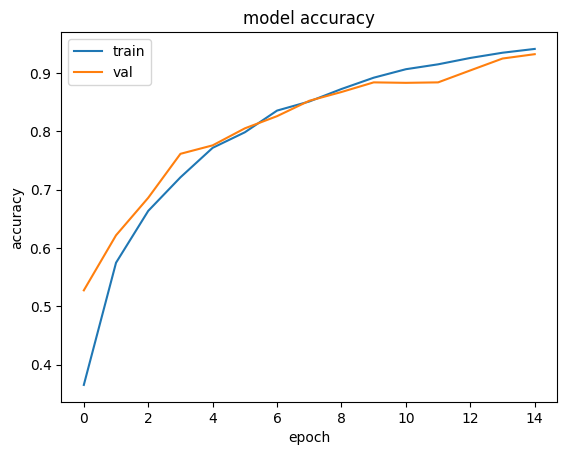

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

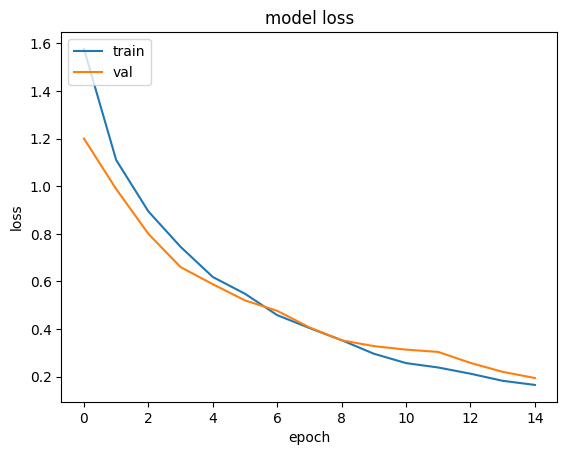

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [19]:
model.load_weights('model.h5')

# Тестирование модели

In [20]:
# loss, acc = model.evaluate(X_test, Y_test, verbose=2)

# Использование модели

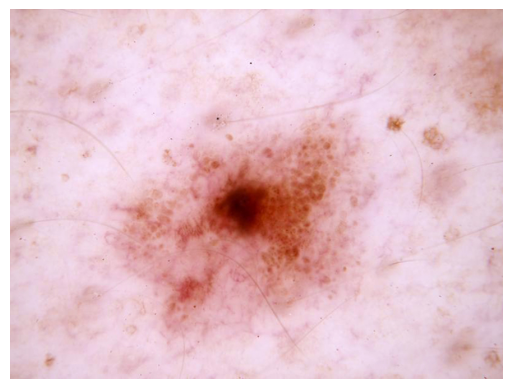

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
result: [[0. 0. 0. 0. 0. 1. 0.]]
('vasc', ' pyogenic granulomas and hemorrhage')


In [21]:
srcdir = './skin-cancer-mnist-ham10000/HAM10000_images_part_1'
count=0
for temp in os.listdir(srcdir):
    img = cv2.imread(os.path.join(srcdir, temp))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()
    img = cv2.resize(img, (28, 28))
    result = model.predict(img.reshape(1, 28, 28, 3))
    print('result:', result)
    max_prob = max(result[0])
    class_ind = list(result[0]).index(max_prob)
    class_name = classes[class_ind]
    print(class_name)
    count+=1
    if count>0:
        break

In [22]:
model.export('saved_model')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  13458096592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458097552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458096208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458106384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458099088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458099856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458099280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458097936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458100624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458098512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13458101200: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [23]:
mlmodel = ct.convert(
    model,
    inputs=[
        ct.ImageType(
            name="conv2d_input",
            shape=(1, 28, 28, 3),
            scale=1/255.0,
            color_layout="RGB"
        )
    ]
)

mlmodel.save("SkinCancerClassifier.mlmodel")

NameError: name 'ct' is not defined